This file contains codes to get plots very similar to the ones in the paper by Fujii and Nakajima.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ---- Global Task & Data Parameters ----
n_values = [2, 5, 10, 15, 20]
washout, train, test = 1000, 3000, 1000
num_samples = washout + train + test  # 5000 total samples
max_n = max(n_values)
total_steps = max_n + 100 + num_samples

# ---- 1. SUPERIMPOSED SINE WAVE INPUT GENERATION ----
# Equation: s_k = 0.1 * [ sin(2*pi*alpha*k/T) * sin(2*pi*beta*k/T) * sin(2*pi*gamma*k/T) + 1 ]
alpha, beta, gamma = 2.11, 3.73, 4.11
T = 100.0
k_indices = np.arange(total_steps)

s_raw = 0.1 * (
    np.sin(2.0 * np.pi * alpha * k_indices / T)
    * np.sin(2.0 * np.pi * beta * k_indices / T)
    * np.sin(2.0 * np.pi * gamma * k_indices / T)
    + 1.0
)

# ---- Generate NARMA Targets Y ----
Y = np.zeros((num_samples, len(n_values)))
for idx, n in enumerate(n_values):
    y_raw = np.zeros(total_steps)
    for i in range(n, total_steps):
        if n == 2:
            y_raw[i] = (
                0.4 * y_raw[i - 1]
                + 0.4 * y_raw[i - 1] * y_raw[i - 2]
                + 0.6 * (s_raw[i - 1] ** 3)
                + 0.1
            )
        else:
            y_raw[i] = (
                0.1
                + 1.5 * s_raw[i - n] * s_raw[i - 1]
                + 0.05 * y_raw[i - 1] * np.sum(y_raw[i - n : i])
                + 0.3 * y_raw[i - 1]
            )
    Y[:, idx] = y_raw[-num_samples:]

# Rescale input s_k to [0, 1] for state injection
S = (s_raw[-num_samples:]).flatten()

# Dataset Splits
S_washout = S[0:washout]
S_train, Y_train = S[washout : washout + train], Y[washout : washout + train]
S_test, Y_test = S[washout + train : num_samples], Y[washout + train : num_samples]

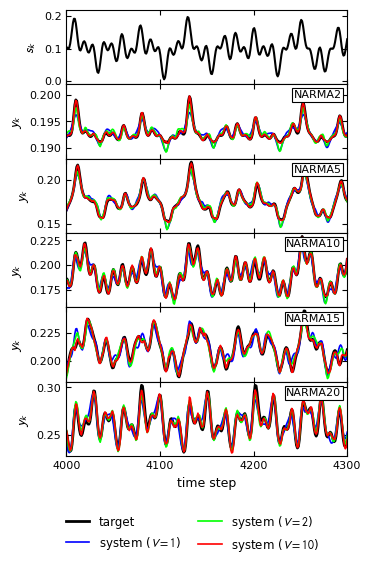

In [5]:
# PLOT FOR NARMA FIG 1

# load data
data = np.load('Data/Reproduction_1/nmse_table1_results.npz')
y_target = data['y_target']
y_pred = data['y_pred']

# Set publication/presentation styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'stixsans'

# 1. GENERATE DUMMY DATA (Replace with your actual arrays)
np.random.seed(42)
t = np.linspace(4000, 4300, 300)

# Input signal s_k0.10 + 0.05 * np.sin(0.1 * t) + 0.03 * np.cos(0.23 * t) + 0.02 * np.sin(0.05 * t)
s_k = S_test

# Tasks and target/system predictions
narma_tasks = ['NARMA2', 'NARMA5', 'NARMA10', 'NARMA15', 'NARMA20']
#y_targets = [
#    0.196 + 0.003 * np.sin(0.12 * t) + 0.002 * np.cos(0.27 * t),
#    0.18  + 0.020 * np.sin(0.08 * t) + 0.015 * np.cos(0.15 * t),
#    0.18  + 0.025 * np.sin(0.15 * t) + 0.010 * np.cos(0.30 * t),
#    0.20  + 0.025 * np.sin(0.11 * t) + 0.015 * np.cos(0.21 * t),
#    0.24  + 0.030 * np.sin(0.18 * t) + 0.020 * np.cos(0.25 * t),
#]

# 2. CREATE FIGURE AND SUBPLOTS
# Dimensions optimized for a single Beamer column (~3.5 inches wide)
fig, axes = plt.subplots(
    nrows=6, ncols=1, 
    figsize=(3.6, 5.8), #(it was 3.6,5.8) 
    sharex=True, 
    gridspec_kw={'hspace': 0}
)

# Colors matching the image
color_target = 'black'
color_v1 = 'blue'
color_v2 = '#00FF00'  # Lime green
color_v10 = 'red'

# 3. PLOT TOP SUBPLOT (Input s_k)
axes[0].plot(t, s_k[100:400], color=color_target, lw=1.5)
axes[0].set_ylabel(r'$s_k$', fontsize=10)
axes[0].set_ylim(-0.01, 0.22)
axes[0].set_yticks([0, 0.10, 0.20])


# 4. PLOT NARMA SUBPLOTS (y_k)
for i, task in enumerate(narma_tasks):
    ax = axes[i + 1]
    target = y_target[:,i]
    
    # Generate variations for V=1, V=2, V=10 tracking target
    pred_v1 = y_pred[0,:,i]
    pred_v2 = y_pred[1,:,i]
    pred_v10 = y_pred[3,:,i]
    
    # Plot lines
    l1, = ax.plot(t, target[100:400], color=color_target, lw=2.0)
    l2, = ax.plot(t, pred_v1[100:400], color=color_v1, lw=1.2)
    l3, = ax.plot(t, pred_v2[100:400], color=color_v2, lw=1.2)
    l4, = ax.plot(t, pred_v10[100:400], color=color_v10, lw=1.2)
    
    ax.set_ylabel(r'$y_k$', fontsize=10)
    
    # Task box label in top-right
    ax.text(
        0.98, 0.92, task, transform=ax.transAxes, 
        fontsize=8, fontweight='normal', ha='right', va='top',
        bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='black', linewidth=0.8)
    )

# 5. AXIS FORMATTING & TICKS
for ax in axes:
    ax.tick_params(
        axis='both', which='both', 
        direction='in', top=True, right=True, 
        labelsize=8
    )

# Bottom X-axis formatting
axes[-1].set_xlabel('time step', fontsize=9)
axes[-1].set_xlim(4000, 4300)
axes[-1].set_xticks([4000, 4100, 4200, 4300])

# 6. LEGEND SETUP BELOW PLOT
legend_labels = ['target', r'system ($V=1$)', r'system ($V=2$)', r'system ($V=10$)']
legend_handles = [l1, l2, l3, l4]

fig.legend(
    legend_handles, legend_labels,
    loc='upper center', 
    bbox_to_anchor=(0.53, 0.10), # Adjusted y-position from 0.05 to 0.10
    ncol=2, 
    frameon=False, 
    fontsize=8.5,
    handlelength=2.0,
    columnspacing=1.5
)

# Avoid tick label overlap on NARMA2
axes[1].set_ylim(0.188, 0.202)

# Adjust layout: increased bottom margin from 0.13 to 0.18
plt.subplots_adjust(bottom=0.18, top=0.95, left=0.18, right=0.96)

# Save high-res PNG with bbox_inches='tight' to capture outer legend
#plt.savefig('Plots/narma_fig1.png', dpi=300, bbox_inches='tight')
plt.show()

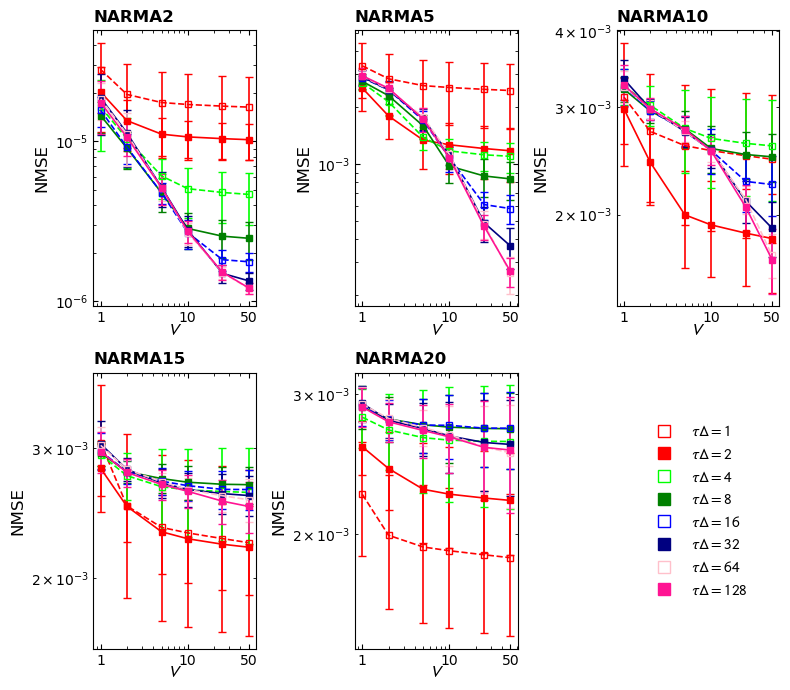

In [6]:
## PLOT FOR NARMA FIG 2

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Data ---
data = np.load("Data/Reproduction_1/nmse_grid_results.npz")
nmse_mean = data['NMSE_MEAN']  # Shape: (n_taus, n_Vs, n_tasks)
nmse_std  = data['NMSE_STD']   # Shape: (n_taus, n_Vs, n_tasks)
tau_list  = data['tau_list']
V_list    = data['V_list']
n_values  = [2, 5, 10, 15, 20]

# --- 2. Plotting Configurations ---
# Color palette matching the reference image
colors = [
    '#FF0000',  # Red (open square)
    '#FF0000',  # Red (filled square)
    '#00FF00',  # Lime (open square)
    '#008000',  # Green (filled square)
    '#0000FF',  # Blue (open square)
    '#000080',  # Dark Blue (filled square)
    '#FFC0CB',  # Light Pink (open square)
    '#FF1493'   # Deep Pink (filled square)
]

# Configure 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 7)) # FOR FULL SIZE DOCUMENT FIGSIZE=(10,9)
axes = axes.flatten()

# Tasks to plot per subplot
task_titles = ["NARMA2", "NARMA5", "NARMA10", "NARMA15", "NARMA20"]

for t_idx, n_val in enumerate(n_values):
    ax = axes[t_idx]
    
    # Iterate through tau values
    for tau_idx, tau in enumerate(tau_list):
        if tau_idx >= len(colors):
            break
            
        color = colors[tau_idx]
        is_filled = (tau_idx % 2 == 1)
        
        y_mean = nmse_mean[tau_idx, :, t_idx]
        y_std  = nmse_std[tau_idx, :, t_idx]
        
        # Plot errorbar curves
        ax.errorbar(
            V_list, y_mean, yerr=y_std,
            fmt='s-' if is_filled else 's--',
            color=color,
            mfc=color if is_filled else 'none',
            mec=color,
            capsize=3,
            linewidth=1.2,
            markersize=5,
            label=f"$\\tau\\Delta={int(tau)}$" if t_idx == 0 else ""
        )
    
    # Styling to match the original figure
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(task_titles[t_idx], fontsize=12, loc='left', fontweight='bold')
    ax.set_xlabel('$V$', fontsize=12, labelpad=-2)
    ax.set_ylabel('NMSE', fontsize=12)
    ax.set_xticks([1, 10, 50])
    ax.set_xticklabels(['1', '10', '50'])
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# --- 3. Format Legend Box in Subplot Slot 6 ---
ax_legend = axes[5]
ax_legend.axis('off')

# Custom legend handles
from matplotlib.lines import Line2D
legend_elements = []
for tau_idx, tau in enumerate(tau_list[:8]):
    color = colors[tau_idx]
    is_filled = (tau_idx % 2 == 1)
    legend_elements.append(
        Line2D([0], [0], marker='s', color='w', label=f"$\\tau\\Delta = {2**tau_idx}$",
               markerfacecolor=color if is_filled else 'none',
               markeredgecolor=color, markersize=8)
    )

ax_legend.legend(handles=legend_elements, loc='center', frameon=False, fontsize=11)

plt.tight_layout()
#plt.savefig("narma_fig2.png", dpi=300)
#print("Plot generated and saved as 'reproduction_plot.png'.")